# **Вариант A: Мини-система стабилизации камеры**

### **Задание**

1. Выбрать видеоролик с заметной дрожью камеры (телефонная съёмка, action-камера, GoPro, записанная вручную панорама).
2. Вычислить плотный оптический поток (Farnebäck) или разреженный (LK) и оценить глобальное движение камеры по кадрам (аффинная модель или гомография).
3. Сгладить траекторию движения низкочастотным фильтром (скользящее окно, экспоненциальное сглаживание или фильтр Калмана по желанию).
4. Выполнить **компенсацию движения** через warp каждого кадра к стабилизированной траектории.
5. Сформировать стабилизированное видео.
6. Построить визуальные сравнения «до/после» и провести **error analysis**: какие участки стабилизируются плохо и почему (оптический поток, тени, motion blur, нехватка текстуры, ошибки глобальной модели).


In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [29]:
input_path = "/content/video_for_hw_1.mp4"
output_path = "/content/stabilized.mp4"
cap = cv2.VideoCapture(input_path)

n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# считываем видео по кадрам
frames = []
frames_color = []
for i in range(n_frames):
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
    ret, frame = cap.read()
    if not ret:
        break
    frames_color.append(frame)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    frames.append(gray)

cap.release()
print("Picked frames:", len(frames), "=> motions:", len(frames)-1)

transforms=[]
for i in range(len(frames) - 1):
    prev = frames[i]
    nxt  = frames[i+1]

    # ключевые точки на предыдущем кадре
    p0 = cv2.goodFeaturesToTrack(prev, maxCorners=1000, qualityLevel=0.01, minDistance=7)
    if p0 is None:
        print(f"[{i}] no features")
        continue

    # Lucas–Kanade
    p1, st, err = cv2.calcOpticalFlowPyrLK(prev, nxt, p0, None,
                                           winSize=(21,21), maxLevel=3,
                                           criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01))

    st = st.reshape(-1).astype(bool)
    p0f = p0[st].reshape(-1, 2)
    p1f = p1[st].reshape(-1, 2)

    if len(p0f) < 6:
        print(f"[{i}] too few tracked points:", len(p0f))
        continue

    # аффинное преобразование (частичное: rot+scale+trans)
    M, inliers = cv2.estimateAffinePartial2D(p0f, p1f, method=cv2.RANSAC, ransacReprojThreshold=3.0)

    if M is None:
        print(f"[{i}] affine failed")
        continue

    inlier_count = int(inliers.sum()) if inliers is not None else 0

    # интерпретация M = [[a b tx],[c d ty]]
    dx, dy = float(M[0,2]), float(M[1,2])
    rot = np.degrees(np.arctan2(M[1,0], M[0,0]))
    scale = np.sqrt(M[0,0]**2 + M[1,0]**2)

    print(f"[{i}] inliers={inlier_count}/{len(p0f)}  dx={dx:.2f} dy={dy:.2f}  rot={rot:.2f}deg  scale={scale:.4f}")
    transforms.append([dx, dy, rot, scale, inlier_count, len(p0f)])

Picked frames: 148 => motions: 147
[0] inliers=843/870  dx=-1.34 dy=4.45  rot=-0.11deg  scale=1.0009
[1] inliers=910/997  dx=-0.88 dy=2.84  rot=-0.08deg  scale=1.0007
[2] inliers=920/1000  dx=-1.15 dy=1.67  rot=-0.08deg  scale=1.0006
[3] inliers=927/1000  dx=-0.83 dy=0.59  rot=-0.06deg  scale=1.0008
[4] inliers=962/1000  dx=-0.89 dy=0.54  rot=-0.10deg  scale=1.0007
[5] inliers=972/997  dx=-1.27 dy=0.21  rot=-0.06deg  scale=1.0013
[6] inliers=991/1000  dx=-1.60 dy=0.57  rot=-0.11deg  scale=1.0006
[7] inliers=986/999  dx=-2.10 dy=0.66  rot=-0.10deg  scale=1.0012
[8] inliers=995/1000  dx=-1.89 dy=0.46  rot=-0.09deg  scale=1.0010
[9] inliers=996/1000  dx=-1.70 dy=0.44  rot=-0.10deg  scale=1.0003
[10] inliers=997/1000  dx=-1.58 dy=0.24  rot=-0.09deg  scale=1.0006
[11] inliers=998/1000  dx=-1.50 dy=0.18  rot=-0.08deg  scale=1.0006
[12] inliers=997/999  dx=-1.54 dy=0.11  rot=-0.08deg  scale=1.0007
[13] inliers=999/1000  dx=-1.38 dy=0.12  rot=-0.08deg  scale=1.0004
[14] inliers=1000/1000  dx=-

In [46]:
# экспоненциальное сглаживание
def exponential_smoothing(signal, alpha=0.1):
    """
    signal: 1D array
    alpha: smoothing factor in (0, 1]

    Чем меньше alpha, тем сильнее сглаживание.
    """
    signal = np.asarray(signal, dtype=np.float64)
    smoothed = np.zeros_like(signal)

    smoothed[0] = signal[0]
    for i in range(1, len(signal)):
        smoothed[i] = alpha * signal[i] + (1.0 - alpha) * smoothed[i - 1]

    return smoothed


def smooth_trajectory_exponential(transforms, alpha_xy=0.1, alpha_a=0.1):
    """
    transforms: array of shape (N-1, 3), columns [dx, dy, da]

    returns:
        trajectory: original cumulative trajectory, shape (N-1, 3)
        smoothed_trajectory: smoothed cumulative trajectory
        new_transforms: corrected transforms
    """
    transforms = np.asarray(transforms, dtype=np.float64)

    dx = transforms[:, 0]
    dy = transforms[:, 1]
    da = transforms[:, 2]

    # исходная траектория
    x = np.cumsum(dx)
    y = np.cumsum(dy)
    a = np.cumsum(da)

    trajectory = np.vstack([x, y, a]).T

    # сглаживание каждой компоненты
    smooth_x = exponential_smoothing(x, alpha=alpha_xy)
    smooth_y = exponential_smoothing(y, alpha=alpha_xy)
    smooth_a = exponential_smoothing(a, alpha=alpha_a)

    smoothed_trajectory = np.vstack([smooth_x, smooth_y, smooth_a]).T

    # разница между сглаженной и исходной траекторией
    diff = smoothed_trajectory - trajectory

    # корректируем исходные межкадровые преобразования
    new_transforms = transforms.copy()
    new_transforms[:, 0] += diff[:, 0]
    new_transforms[:, 1] += diff[:, 1]
    new_transforms[:, 2] += diff[:, 2]

    return trajectory, smoothed_trajectory, new_transforms

# применяем экспоненциальное сглаживание
trajectory, smoothed_trajectory, new_transforms = smooth_trajectory_exponential(
    transforms,
    alpha_xy=0.05,
    alpha_a=0.05
)

In [47]:
def fix_border(frame, scale=1.04):
    """
    Немного увеличивает кадр, чтобы скрыть черные края после warpAffine.
    """
    h, w = frame.shape[:2]
    center = (w / 2, h / 2)

    # матрица масштабирования вокруг центра кадра
    T = cv2.getRotationMatrix2D(center, 0, scale)

    # применяем увеличение
    return cv2.warpAffine(frame, T, (w, h))


def stabilize_video_with_warp(
    input_path,
    output_path,
    new_transforms,
    angle_in_degrees=True,
    border_mode=cv2.BORDER_REFLECT,
    fix_border_flag=True,
    fix_border_scale=1.04
):
    """
    Создает стабилизированное видео по рассчитанным скорректированным преобразованиям.

    Parameters
    ----------
    input_path : str
        Путь к исходному видео.
    output_path : str
        Путь, куда сохранить стабилизированное видео.
    new_transforms : np.ndarray, shape (N-1, 3)
        Скорректированные межкадровые преобразования:
        [dx, dy, da] для каждого перехода между кадрами.
    angle_in_degrees : bool
        True, если da хранится в градусах.
        False, если da уже в радианах.
    border_mode : int
        Режим заполнения областей вне кадра при warpAffine.
    fix_border_flag : bool
        Нужно ли немного увеличивать кадр после warp, чтобы скрывать края.
    fix_border_scale : float
        Коэффициент увеличения кадра.
    """

    new_transforms = np.asarray(new_transforms, dtype=np.float64)

    # Открываем исходное видео
    cap = cv2.VideoCapture(input_path)
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {input_path}")

    # Считываем параметры видео
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    if fps <= 0:
        fps = 25.0

    # Создаем объект для записи выходного видео
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(output_path, fourcc, fps, (w, h))

    # Читаем первый кадр
    ret, first_frame = cap.read()
    if not ret:
        cap.release()
        out.release()
        raise ValueError("Cannot read first frame from input video")

    # Первый кадр без преобразования
    out.write(first_frame)

    frame_idx = 0
    stabilized_frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        dx = float(new_transforms[frame_idx, 0])
        dy = float(new_transforms[frame_idx, 1])
        da = float(new_transforms[frame_idx, 2])

        # Приводим угол к радианам, если он в градусах
        if angle_in_degrees:
            da = np.deg2rad(da)

        # Строим матрицу преобразования для warpAffine
        cos_a = np.cos(da)
        sin_a = np.sin(da)

        M = np.array([
            [cos_a, -sin_a, dx],
            [sin_a,  cos_a, dy]
        ], dtype=np.float32)

        # Применяем warpAffine
        stabilized = cv2.warpAffine(
            frame,
            M,
            (w, h),
            flags=cv2.INTER_LINEAR,
            borderMode=border_mode
        )

        # При необходимости немного увеличиваем кадр
        if fix_border_flag:
            stabilized = fix_border(stabilized, scale=fix_border_scale)

        out.write(stabilized)
        stabilized_frames.append(stabilized)
        frame_idx += 1

    cap.release()
    out.release()

    print(f"Saved stabilized video to: {output_path}")
    return stabilized_frames

# формируем стабилизированное видео
stabilized_frames = stabilize_video_with_warp(
    input_path=input_path,
    output_path=output_path,
    new_transforms=new_transforms,
    angle_in_degrees=True,
    border_mode=cv2.BORDER_REFLECT,
    fix_border_flag=True,
    fix_border_scale=1.03
)

Saved stabilized video to: /content/stabilized.mp4


# Визуализация

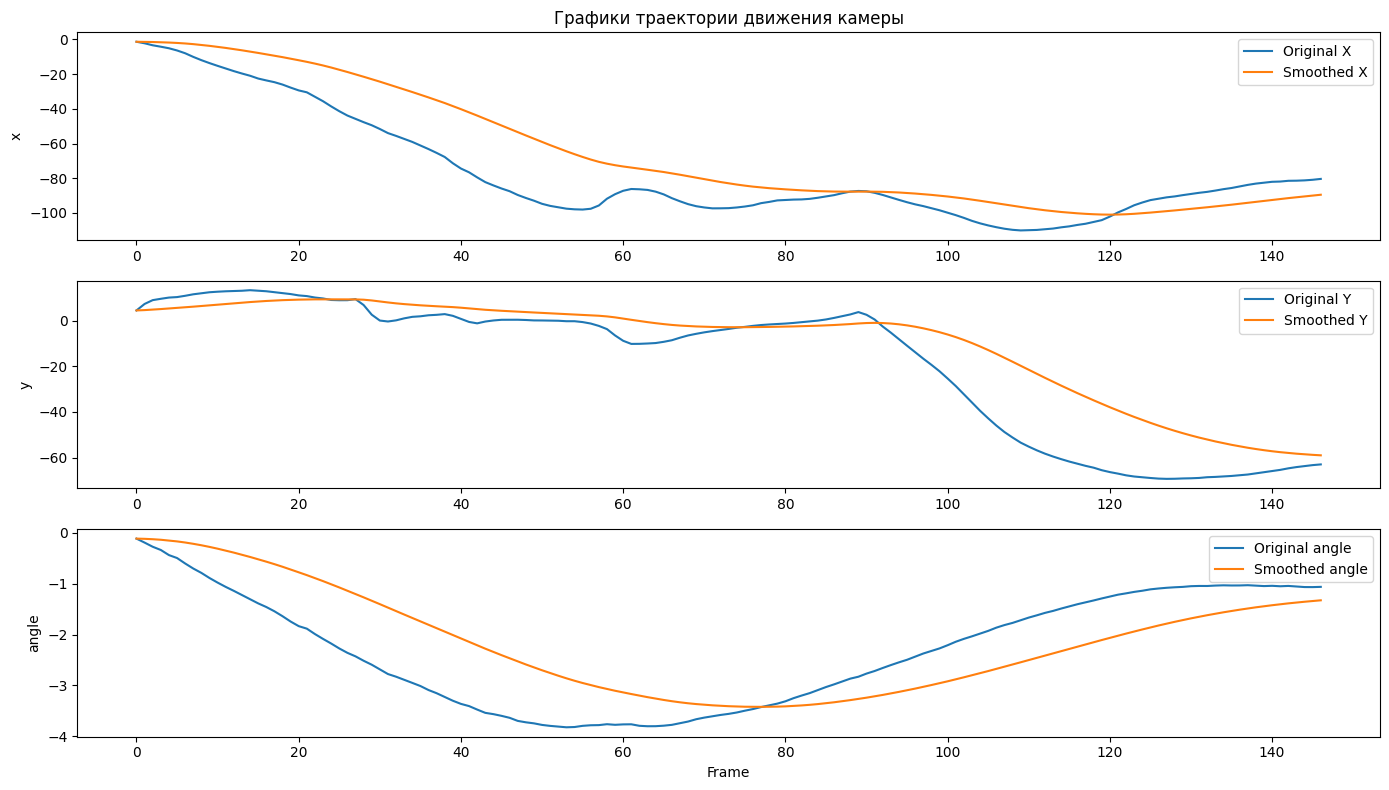

In [48]:
plt.figure(figsize=(14, 8))

plt.subplot(3, 1, 1)
plt.plot(trajectory[:, 0], label="Original X")
plt.plot(smoothed_trajectory[:, 0], label="Smoothed X")
plt.legend()
plt.title('Графики траектории движения камеры')
plt.ylabel("x")

plt.subplot(3, 1, 2)
plt.plot(trajectory[:, 1], label="Original Y")
plt.plot(smoothed_trajectory[:, 1], label="Smoothed Y")
plt.legend()
plt.ylabel("y")

plt.subplot(3, 1, 3)
plt.plot(trajectory[:, 2], label="Original angle")
plt.plot(smoothed_trajectory[:, 2], label="Smoothed angle")
plt.legend()
plt.ylabel("angle")
plt.xlabel("Frame")

plt.tight_layout()
plt.show()

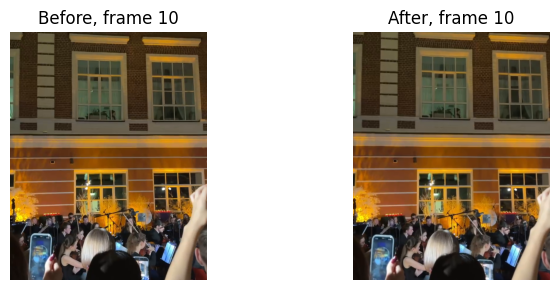

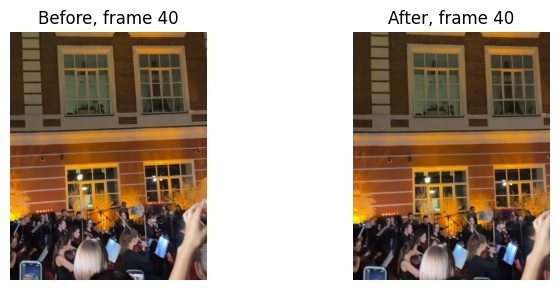

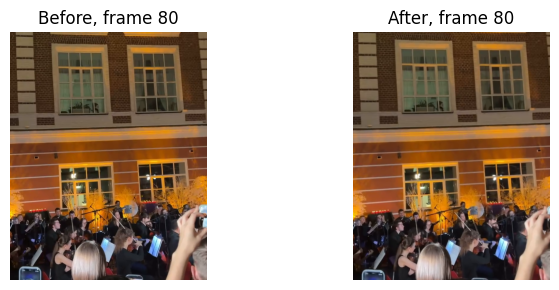

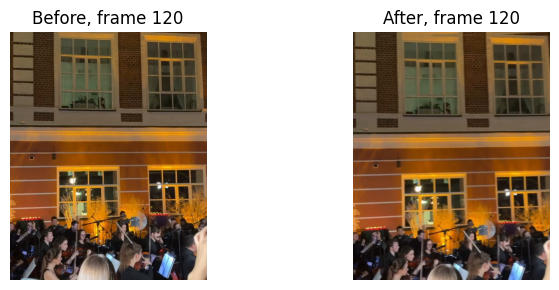

In [49]:
frame_ids = [10, 40, 80, 120]

for idx in frame_ids:
    if idx >= len(frames_color) or idx >= len(stabilized_frames):
        continue

    orig = frames_color[idx]
    stab = stabilized_frames[idx]

    orig_rgb = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
    stab_rgb = cv2.cvtColor(stab, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 3))

    plt.subplot(1, 2, 1)
    plt.imshow(orig_rgb)
    plt.title(f"Before, frame {idx}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(stab_rgb)
    plt.title(f"After, frame {idx}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

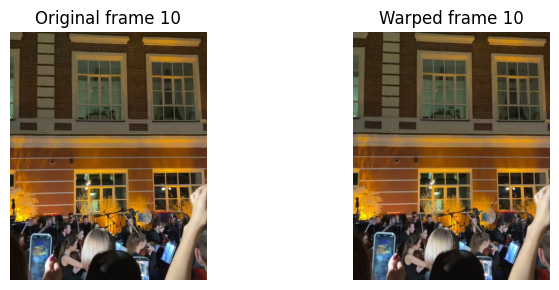

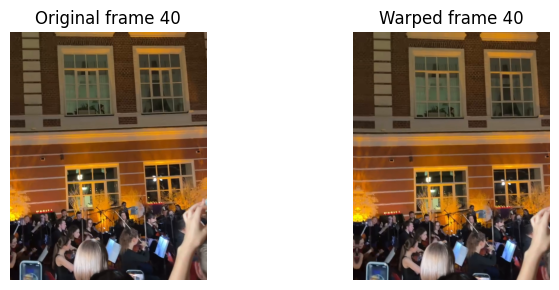

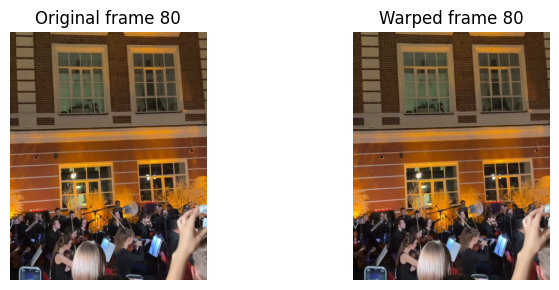

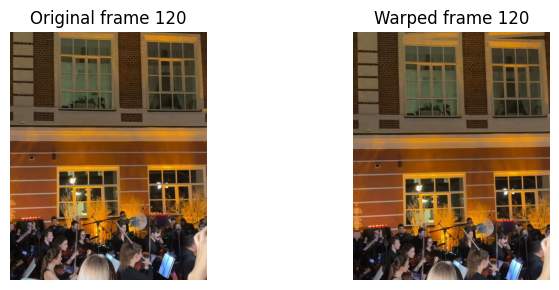

In [50]:
for idx in frame_ids:
    if idx == 0 or idx >= len(frames_color):
        continue
    if idx - 1 >= len(new_transforms):
        continue

    frame = frames_color[idx].copy()

    dx = float(new_transforms[idx - 1, 0])
    dy = float(new_transforms[idx - 1, 1])
    da = float(new_transforms[idx - 1, 2])

    da = np.deg2rad(da)

    cos_a = np.cos(da)
    sin_a = np.sin(da)

    h, w = frame.shape[:2]

    M = np.array([
        [cos_a, -sin_a, dx],
        [sin_a,  cos_a, dy]
    ], dtype=np.float32)

    warped = cv2.warpAffine(
        frame,
        M,
        (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT
    )

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    warped_rgb = cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 3))

    plt.subplot(1, 2, 1)
    plt.imshow(frame_rgb)
    plt.title(f"Original frame {idx}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(warped_rgb)
    plt.title(f"Warped frame {idx}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()